# assignment step 2: hidden test set evaluation and checkpoint loading

`Jacob Poirier`

The code in this notebook is loading the checkpoint created by the first notebook for the model, and does not do training, only evaluating and inferencing based on the new info in hidden test csv


# Libraries that are required, some have already been downloaded in the first notebook, but just doing to be sure


In [20]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)


## Loading the model checkpoint from step 1


In [21]:
MODEL_PATH = "model_checkpoint/sentiment_model.joblib"
HIDDEN_TEST_PATH = "hidden_test_with_labels.csv"

model = joblib.load(MODEL_PATH)

print("model loaded successfuly:")
print(model)


model loaded successfuly:
Pipeline(steps=[('vectorizer',
                 CountVectorizer(max_features=20000, strip_accents='unicode')),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42, solver='liblinear'))])


## Loading the hidden test file

Labels for the data are not used, only considering the text for evaluation.


In [28]:
hidden_test = pd.read_csv(HIDDEN_TEST_PATH)

print("hidden test shape:", hidden_test.shape)
print("columns:", hidden_test.columns.tolist())
print("\nclass distrib:")
print(hidden_test["label"].value_counts())


hidden test shape: (600, 5)
columns: ['id', 'text', 'label', 'label_name', 'source_file']

class distrib:
label
0    300
1    300
Name: count, dtype: int64


## generating predictions

As stated, these predictions are made directly from the checkpoint created after step 1 of the assignment.


In [23]:
X_hidden = hidden_test["text"].fillna("").astype(str)

hidden_predictions = model.predict(X_hidden).astype(int)

print("number of predictions:", len(hidden_predictions))
print("predicted labels:")
print(pd.Series(hidden_predictions).value_counts().sort_index())


number of predictions: 600
predicted labels:
0    163
1    437
Name: count, dtype: int64


## Creating the hidden_test_predictions csv file



In [24]:
predictions_df = pd.DataFrame({
    "id": hidden_test["id"],
    "predicted_label": hidden_predictions
})

predictions_df.to_csv(
    "hidden_test_predictions.csv",
    index=False
)

print(predictions_df.head())
print("\ncolumns:", predictions_df.columns.tolist())
print("rows:", len(predictions_df))


                id  predicted_label
0  neg_cv795_10291                0
1   neg_cv174_9735                0
2  pos_cv065_15248                1
3  neg_cv076_26009                1
4  neg_cv417_14653                1

columns: ['id', 'predicted_label']
rows: 600


## Hidden test accuracy

In [25]:
y_hidden = hidden_test["label"].astype(int)

hidden_accuracy = accuracy_score(
    y_hidden,
    hidden_predictions
)

print(f"Hidden test accuracy: {hidden_accuracy:.4f}")
print(f"Hidden test accuracy: {hidden_accuracy * 100:.2f}%")


Hidden test accuracy: 0.6583
Hidden test accuracy: 65.83%


## Hidden test confusion matrix



confusion matrix:
[[129 171]
 [ 34 266]]


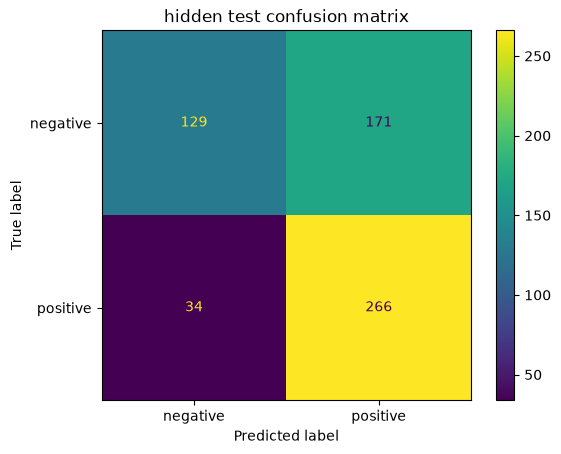

In [26]:
hidden_cm = confusion_matrix(
    y_hidden,
    hidden_predictions
)

print("confusion matrix:")
print(hidden_cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=hidden_cm,
    display_labels=["negative", "positive"]
)

disp.plot()
plt.title("hidden test confusion matrix")
plt.show()


## classification report

In [27]:
print(
    classification_report(
        y_hidden,
        hidden_predictions,
        target_names=["negative", "positive"]
    )
)


              precision    recall  f1-score   support

    negative       0.79      0.43      0.56       300
    positive       0.61      0.89      0.72       300

    accuracy                           0.66       600
   macro avg       0.70      0.66      0.64       600
weighted avg       0.70      0.66      0.64       600



## comparison to the results of the public test data

With the step 1 checkpoint, the public test accuracy was about **67.50%**.

The hidden test accuracy is **65.83%**.

This is a decrease of around 2 percent from the public test results. The results are reasonably close, meaning that the model's performance is not significantly different on the hidden examples. However, the model still tends to have difficulty identifying negative reviews. On the hidden test set for example, it correctly classified 129 of 300 negative reviews while correctly classifying 266 of 300 positive reviews, this is obviously very skewed and is something I feel could be improved upon given more time.

The similar overall accuracy scores also shows how accuracy alone does not tell the complete story. The confusion matrix provides some additional information about which sentiment class is being misclassified, in this case it tends to be negative reviews.


## what to try going forward

If I had more time or compute, I would try comparing the different tune regularization strengths using cross validation on the training set, or possibly using a pretrained language model designed for this specific kind of text classification. 


